# Data vergelijking: EM-DAT rampen vs. ERA5 risicoclassificatie

Dit notebook vergelijkt **gedocumenteerde rampen** uit de EM-DAT database met de **berekende risico's** op basis van ERA5 klimaatindices voor **Jijiga City** (Somalische regio, Ethiopië).

**ERA5 locatie:** 42.75°E / 9.25°N (dichtstbijzijnde gridpunt bij Jijiga)  
**Periode:** 2000–2025  
**Risicotypes:** Droogte (SPEI + API + SMI + Afvoer) en Overstroming (SPEI + API + SMI + Afvoer)

In [1]:
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")
from modeling import DroughtRiskClassifier, FloodRiskClassifier, RiskLevel

# Paden
ERA5_PATH  = "../src/data/processed/era5_2000_2025.parquet"
EMDAT_PATH = "../src/data/processed/emdat.xlsx"

RISK_COLORS = {
    RiskLevel.LOW:      "#2ecc71",
    RiskLevel.MODERATE: "#f1c40f",
    RiskLevel.ELEVATED: "#e67e22",
    RiskLevel.HIGH:     "#e74c3c",
    RiskLevel.EXTREME:  "#8e44ad",
}
RISK_NUMERIC = {r: r.numeric for r in RiskLevel}
print("Imports OK")

Imports OK


## 1. ERA5-data laden en risico's berekenen

In [2]:
era5_raw = pd.read_parquet(ERA5_PATH)
era5_raw["time"] = pd.to_datetime(era5_raw["time"])
era5 = era5_raw.set_index("time").sort_index()
era5 = era5.drop(columns=["longitude", "latitude", "number"], errors="ignore")
era5["spei"] = era5["spei"].bfill()

print(f"ERA5 periode : {era5.index.min().date()} → {era5.index.max().date()}")
print(f"Locatie      : lon={era5_raw['longitude'].iloc[0]:.2f}°E, lat={era5_raw['latitude'].iloc[0]:.2f}°N")
print(f"Kolommen     : {list(era5.columns)}")
era5[["spei", "api", "smi", "total_ro"]].describe().round(4)

ERA5 periode : 2000-01-01 → 2025-12-31
Locatie      : lon=42.75°E, lat=9.25°N
Kolommen     : ['u10', 'v10', 'd2m', 't2m', 'sp', 'swvl1', 'swvl2', 'tp', 'ssrd', 'e', 'pev', 'ssro', 'sro', 'lsp', 'vimd', 'total_ro', 'api', 'smi', 'spei']


,spei,api,smi,total_ro
count,9497.0000,9497.0000,9497.0000,9497.0000
mean,-0.0547,0.0011,0.2833,0.0000
std,0.9934,0.0016,0.1938,0.0001
min,-4.7534,0.0000,0.0000,0.0000
25%,-0.7316,0.0001,0.1134,0.0000
50%,0.1146,0.0005,0.2444,0.0000
75%,0.6811,0.0014,0.3979,0.0000
max,2.0590,0.0145,1.0000,0.0020


In [3]:
drought_clf = DroughtRiskClassifier()
drought_clf.fit(era5)
era5["drought_risk"] = drought_clf.classify(era5)

flood_clf = FloodRiskClassifier()
flood_clf.fit(era5)
era5["flood_risk"] = flood_clf.classify(era5)

era5["drought_num"] = era5["drought_risk"].map(RISK_NUMERIC)
era5["flood_num"]   = era5["flood_risk"].map(RISK_NUMERIC)

print("\nDroogte-risikoverdeling:")
print(era5["drought_risk"].value_counts().rename(lambda r: r.value))
print("\nOverstroming-risikoverdeling:")
print(era5["flood_risk"].value_counts().rename(lambda r: r.value))


Droogte-risikoverdeling:
drought_risk
Laag risico         6517
Hoog risico          920
Verhoogd risico      911
Extreem risico       778
Gemiddeld risico     371
Name: count, dtype: int64

Overstroming-risikoverdeling:
flood_risk
Laag risico         6173
Gemiddeld risico    1424
Verhoogd risico      950
Hoog risico          665
Extreem risico       285
Name: count, dtype: int64


## 2. EM-DAT data laden en verkennen

In [4]:
emdat_raw = pd.read_excel(EMDAT_PATH)
print(f"EM-DAT rijen    : {len(emdat_raw):,}")
print(f"EM-DAT kolommen : {list(emdat_raw.columns)}")

EM-DAT rijen    : 1,201
EM-DAT kolommen : ['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


In [5]:
# Kolommen normaliseren voor robuuste matching
emdat_raw.columns = emdat_raw.columns.str.strip()

# Probeer alle mogelijke kolomnamen (EM-DAT versies variëren)
country_col = next(
    (c for c in emdat_raw.columns if "country" in c.lower()), None
)
type_col = next(
    (c for c in emdat_raw.columns if c.lower() in ("disaster type", "disastertype", "type")), None
)
loc_col = next(
    (c for c in emdat_raw.columns if "location" in c.lower()), None
)
start_year_col = next(
    (c for c in emdat_raw.columns if "start year" in c.lower() or c.lower() == "year"), None
)
start_month_col = next(
    (c for c in emdat_raw.columns if "start month" in c.lower()), None
)
start_day_col = next(
    (c for c in emdat_raw.columns if "start day" in c.lower()), None
)
end_year_col = next(
    (c for c in emdat_raw.columns if "end year" in c.lower()), None
)
end_month_col = next(
    (c for c in emdat_raw.columns if "end month" in c.lower()), None
)
end_day_col = next(
    (c for c in emdat_raw.columns if "end day" in c.lower()), None
)

print("Gevonden kolomnamen:")
for name, col in [
    ("land",        country_col),
    ("type",        type_col),
    ("locatie",     loc_col),
    ("startjaar",   start_year_col),
    ("startmaand",  start_month_col),
    ("startdag",    start_day_col),
    ("eindjaar",    end_year_col),
    ("eindmaand",   end_month_col),
    ("einddag",     end_day_col),
]:
    print(f"  {name:12s}: {col}")

Gevonden kolomnamen:
  land        : Country
  type        : Disaster Type
  locatie     : Location
  startjaar   : Start Year
  startmaand  : Start Month
  startdag    : Start Day
  eindjaar    : End Year
  eindmaand   : End Month
  einddag     : End Day


In [6]:
# Filteren: Ethiopië, droogte of overstroming
eth = emdat_raw.copy()

if country_col:
    eth = eth[eth[country_col].str.lower().str.contains("ethiopia", na=False)]

if type_col:
    eth = eth[
        eth[type_col].str.lower().str.contains("flood|drought", na=False)
    ]

print(f"Ethiopische droogte/overstromingsrampen: {len(eth)}")

if type_col:
    print("\nRamptypes:")
    print(eth[type_col].value_counts())

Ethiopische droogte/overstromingsrampen: 48

Ramptypes:
Disaster Type
Flood      39
Drought     9
Name: count, dtype: int64


In [7]:
def build_date(year_s, month_s, day_s, fallback_month=1, fallback_day=1):
    """Bouw een datum op uit aparte jaar/maand/dag-series (EM-DAT stijl)."""
    year  = pd.to_numeric(year_s,  errors="coerce").fillna(0).astype(int)
    month = pd.to_numeric(month_s, errors="coerce").fillna(fallback_month).astype(int)
    day   = pd.to_numeric(day_s,   errors="coerce").fillna(fallback_day).astype(int)
    month = month.clip(1, 12)
    day   = day.clip(1, 28)   # conservatief: 28 is altijd geldig
    dates = []
    for y, m, d in zip(year, month, day):
        try:
            dates.append(pd.Timestamp(year=y, month=m, day=d) if y > 0 else pd.NaT)
        except Exception:
            dates.append(pd.NaT)
    return pd.Series(dates, index=year_s.index)


if start_year_col:
    eth = eth.copy()
    eth["start_date"] = build_date(
        eth[start_year_col],
        eth.get(start_month_col, pd.Series(1, index=eth.index)),
        eth.get(start_day_col,   pd.Series(1, index=eth.index)),
    )
    eth["end_date"] = build_date(
        eth[end_year_col] if end_year_col else eth[start_year_col],
        eth.get(end_month_col, pd.Series(12, index=eth.index)),
        eth.get(end_day_col,   pd.Series(28, index=eth.index)),
        fallback_month=12,
        fallback_day=28,
    )

# Beperk tot ERA5-periode
eth = eth[
    (eth["start_date"] >= era5.index.min()) &
    (eth["start_date"] <= era5.index.max())
].copy()

print(f"Rampen in ERA5-periode (2000–2025): {len(eth)}")
cols_show = [c for c in [country_col, type_col, loc_col, "start_date", "end_date"] if c]
eth[cols_show].sort_values("start_date").head(10)

Rampen in ERA5-periode (2000–2025): 47


,Country,Disaster Type,Location,start_date,end_date
503,Ethiopia,Flood,"Nazareth city (East Shewa district, Oromia pro...",2000-06-28,2000-06-28
504,Ethiopia,Flood,"Dubti area (Zone 1 district, Afar province)",2000-08-10,2000-08-21
770,Ethiopia,Flood,Gambela province,2001-07-01,2001-07-28
72,Ethiopia,Flood,"Himora town (Western district, Tigray province)",2001-08-01,2001-08-28
1194,Ethiopia,Flood,"Dubti, Asaita areas (Zone 1 district, Afar pro...",2001-08-10,2001-08-10
99,Ethiopia,Flood,"Afar, Oromia, Somali region",2002-04-16,2002-04-21
540,Ethiopia,Drought,"Tigray, Oromia, Amhara, Somali, Afar provinces",2003-01-01,2004-12-28
532,Ethiopia,Flood,Somali province,2003-04-28,2003-05-20
362,Ethiopia,Flood,"Dire Dawa, Somali provinces",2005-04-23,2005-04-26
1158,Ethiopia,Flood,Dire Dawa province,2005-05-20,2005-05-22


In [8]:
# Filter op Jijiga / Somalische regio (optioneel — toon ook zonder filter)
jijiga_keywords = ["jijiga", "somali", "ogaden", "jigjiga"]

if loc_col:
    loc_lower = eth[loc_col].fillna("").str.lower()
    eth_jijiga = eth[
        loc_lower.str.contains("|".join(jijiga_keywords), na=False)
    ].copy()
else:
    eth_jijiga = eth.copy()

print(f"Rampen met Jijiga/Somali-locatie: {len(eth_jijiga)}")

# Gebruik brede set als Jijiga-specifiek te klein is
disasters = eth_jijiga if len(eth_jijiga) >= 3 else eth
label_scope = "Jijiga / Somali regio" if len(eth_jijiga) >= 3 else "Ethiopië (breed)"
print(f"Analyse op basis van: {label_scope} ({len(disasters)} rampen)")
disasters[[c for c in [type_col, loc_col, "start_date", "end_date"] if c]].sort_values("start_date")

Rampen met Jijiga/Somali-locatie: 26
Analyse op basis van: Jijiga / Somali regio (26 rampen)


,Disaster Type,Location,start_date,end_date
99,Flood,"Afar, Oromia, Somali region",2002-04-16,2002-04-21
540,Drought,"Tigray, Oromia, Amhara, Somali, Afar provinces",2003-01-01,2004-12-28
532,Flood,Somali province,2003-04-28,2003-05-20
362,Flood,"Dire Dawa, Somali provinces",2005-04-23,2005-04-26
1153,Drought,"Afder, Liben districts (Somali province), Gode...",2005-11-01,2006-12-28
1154,Flood,"Afar, Somali provinces",2006-04-09,2006-04-25
569,Flood,"Gode, Kelafo, Mustahil, East Imi, Ferfer, Dena...",2006-10-27,2006-12-18
1132,Flood,"Gambela, Amhara, SNNPR, Addis Ababa, Afar, Tig...",2007-07-28,2007-10-05
1112,Drought,"Oromia, Somali, Amhara, Afar, Tigray, SNNPR pr...",2008-05-01,2009-10-28
1122,Flood,"Jijiga town (Fafan district, Somali province)",2008-05-28,2008-05-28


## 3. Tijdlijnvergelijking: Droogte

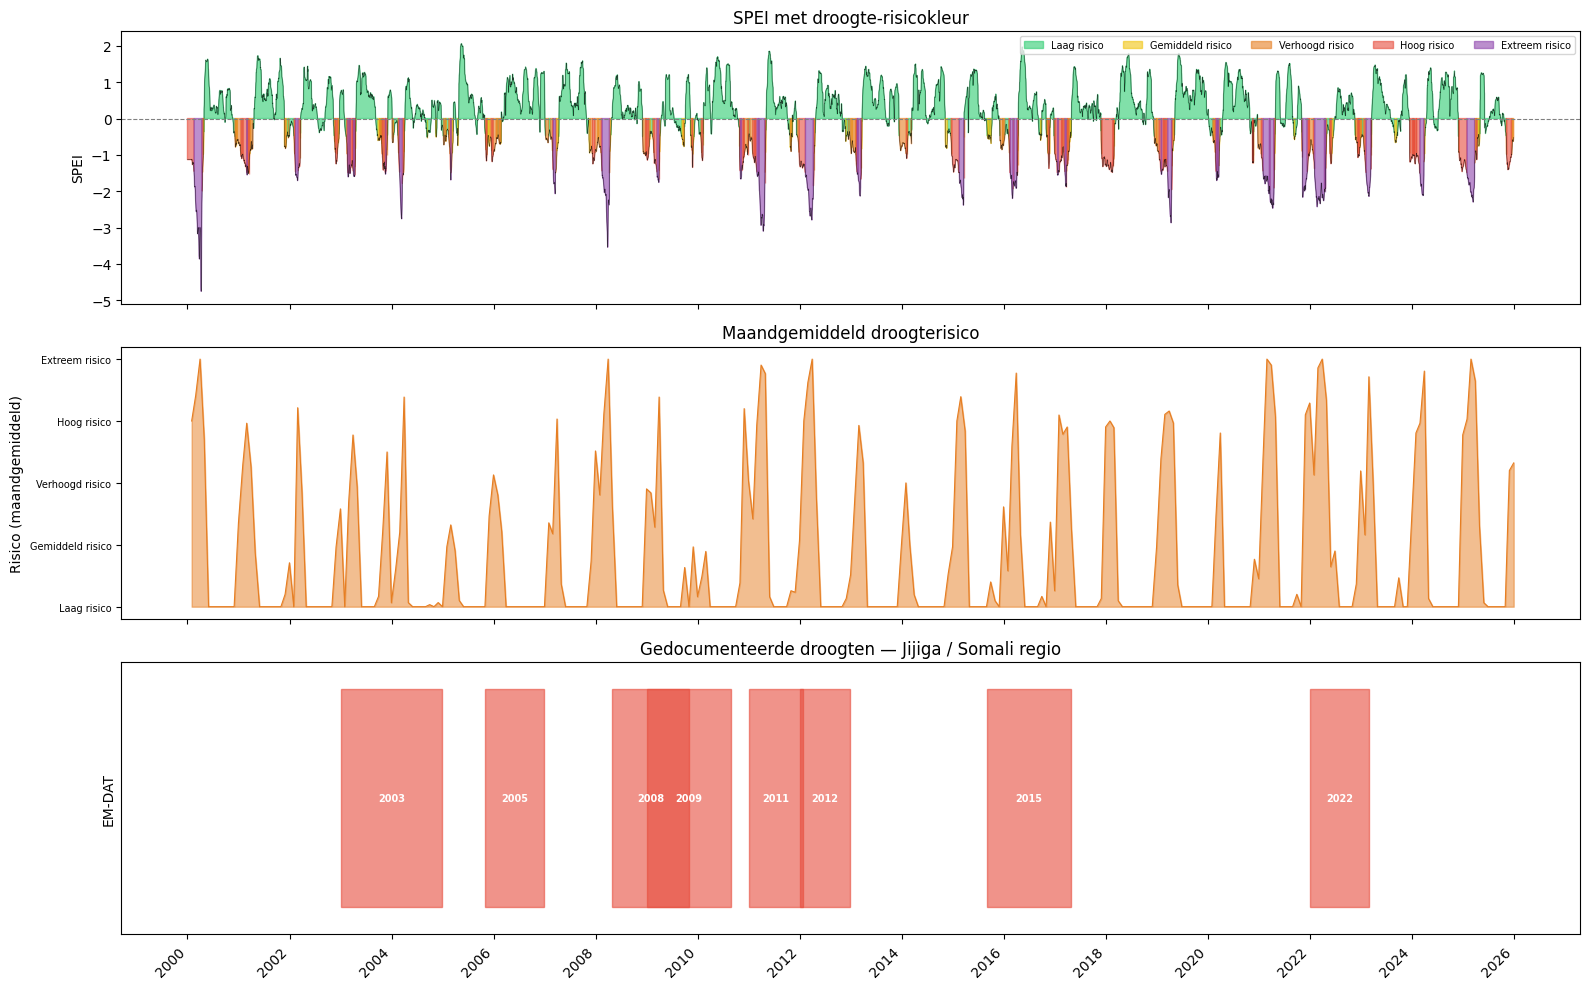

Aantal EM-DAT droogten: 8


In [9]:
drought_events = disasters[
    disasters[type_col].str.lower().str.contains("drought", na=False)
] if type_col else disasters

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# — Paneel 1: SPEI tijdreeks met risicokleur
ax = axes[0]
for level in RiskLevel:
    mask = era5["drought_risk"] == level
    ax.fill_between(era5.index, era5["spei"], where=mask,
                    color=RISK_COLORS[level], alpha=0.6, label=level.value)
ax.plot(era5.index, era5["spei"], color="k", lw=0.4, alpha=0.7)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("SPEI")
ax.set_title("SPEI met droogte-risicokleur")
ax.legend(loc="upper right", fontsize=7, ncol=5)

# — Paneel 2: Droogte-risiconiveau (numeriek)
ax = axes[1]
monthly_drought = era5["drought_num"].resample("ME").mean()
ax.fill_between(monthly_drought.index, monthly_drought, alpha=0.5, color="#e67e22")
ax.plot(monthly_drought.index, monthly_drought, color="#e67e22", lw=0.8)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=7)
ax.set_ylabel("Risico (maandgemiddeld)")
ax.set_title("Maandgemiddeld droogterisico")

# — Paneel 3: EM-DAT droogte-evenementen als gekleurde banden
ax = axes[2]
ax.set_ylabel("EM-DAT")
ax.set_title(f"Gedocumenteerde droogten — {label_scope}")
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
if len(drought_events) > 0:
    for _, row in drought_events.iterrows():
        s = row["start_date"]
        e = row["end_date"] if pd.notna(row["end_date"]) else s + pd.Timedelta(days=30)
        ax.axvspan(s, e, ymin=0.1, ymax=0.9,
                   color="#e74c3c", alpha=0.6, label="Droogte (EM-DAT)")
        ax.text(s + (e - s) / 2, 0.5, str(s.year),
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
else:
    ax.text(0.5, 0.5, "Geen droogten gevonden in gefilterd bereik",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="gray")

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.savefig("droogte_vergelijking.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Aantal EM-DAT droogten: {len(drought_events)}")

## 4. Tijdlijnvergelijking: Overstroming

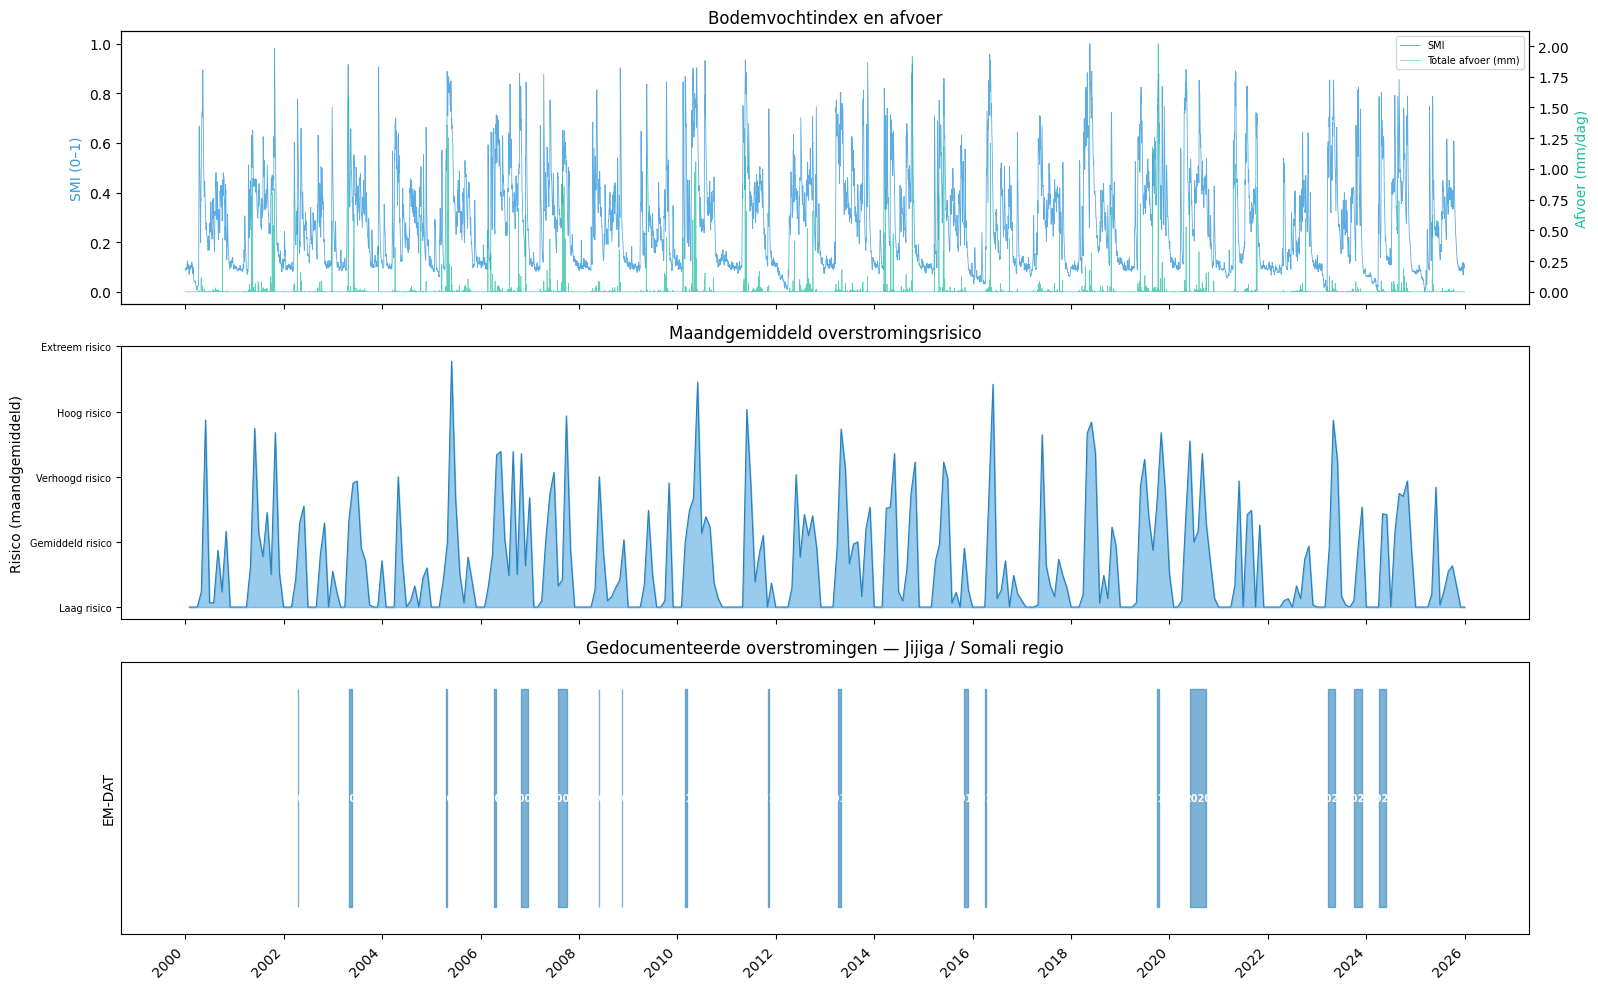

Aantal EM-DAT overstromingen: 18


In [10]:
flood_events = disasters[
    disasters[type_col].str.lower().str.contains("flood", na=False)
] if type_col else disasters

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# — Paneel 1: SMI + totale afvoer
ax = axes[0]
ax2 = ax.twinx()
ax.plot(era5.index, era5["smi"], color="#3498db", lw=0.6, label="SMI", alpha=0.8)
ax2.plot(era5.index, era5["total_ro"] * 1000, color="#1abc9c", lw=0.5,
         label="Totale afvoer (mm)", alpha=0.7)
ax.set_ylabel("SMI (0–1)", color="#3498db")
ax2.set_ylabel("Afvoer (mm/dag)", color="#1abc9c")
ax.set_title("Bodemvochtindex en afvoer")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=7)

# — Paneel 2: Overstromingsrisico (maandgemiddeld)
ax = axes[1]
monthly_flood = era5["flood_num"].resample("ME").mean()
ax.fill_between(monthly_flood.index, monthly_flood, alpha=0.5, color="#3498db")
ax.plot(monthly_flood.index, monthly_flood, color="#2980b9", lw=0.8)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=7)
ax.set_ylabel("Risico (maandgemiddeld)")
ax.set_title("Maandgemiddeld overstromingsrisico")

# — Paneel 3: EM-DAT overstromingen
ax = axes[2]
ax.set_ylabel("EM-DAT")
ax.set_title(f"Gedocumenteerde overstromingen — {label_scope}")
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
if len(flood_events) > 0:
    for _, row in flood_events.iterrows():
        s = row["start_date"]
        e = row["end_date"] if pd.notna(row["end_date"]) else s + pd.Timedelta(days=14)
        ax.axvspan(s, e, ymin=0.1, ymax=0.9,
                   color="#2980b9", alpha=0.6)
        ax.text(s + (e - s) / 2, 0.5, str(s.year),
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
else:
    ax.text(0.5, 0.5, "Geen overstromingen gevonden in gefilterd bereik",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="gray")

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.savefig("overstroming_vergelijking.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Aantal EM-DAT overstromingen: {len(flood_events)}")

## 5. Risiconiveau rondom EM-DAT gebeurtenissen

In [11]:
def risk_during_event(event_row, risk_col, window_days=30):
    """Gemiddeld risiconiveau in de periode rondom een EM-DAT evenement."""
    s = event_row["start_date"] - pd.Timedelta(days=window_days)
    e = (event_row["end_date"]
         if pd.notna(event_row["end_date"])
         else event_row["start_date"]) + pd.Timedelta(days=window_days)
    segment = era5.loc[s:e, risk_col]
    if len(segment) == 0:
        return np.nan
    return segment.mean()


records = []
for _, row in disasters.iterrows():
    t = row[type_col].lower() if type_col else "unknown"
    if "drought" in t:
        risk_mean = risk_during_event(row, "drought_num")
        risk_label = "Droogte"
    elif "flood" in t:
        risk_mean = risk_during_event(row, "flood_num")
        risk_label = "Overstroming"
    else:
        continue
    records.append({
        "type":       risk_label,
        "start_date": row["start_date"],
        "end_date":   row["end_date"],
        "locatie":    row.get(loc_col, "") if loc_col else "",
        "risico_gem": risk_mean,
        "risico_cat": list(RiskLevel)[min(round(risk_mean), 4)].value if not np.isnan(risk_mean) else "N/B",
    })

summary = pd.DataFrame(records).sort_values("start_date")
summary

,type,start_date,end_date,locatie,risico_gem,risico_cat
0,Overstroming,2002-04-16,2002-04-21,"Afar, Oromia, Somali region",1.363636,Gemiddeld risico
12,Droogte,2003-01-01,2004-12-28,"Tigray, Oromia, Amhara, Somali, Afar provinces",0.700508,Gemiddeld risico
11,Overstroming,2003-04-28,2003-05-20,Somali province,1.698795,Verhoogd risico
3,Overstroming,2005-04-23,2005-04-26,"Dire Dawa, Somali provinces",2.078125,Verhoogd risico
24,Droogte,2005-11-01,2006-12-28,"Afder, Liben districts (Somali province), Gode...",0.492754,Laag risico
25,Overstroming,2006-04-09,2006-04-25,"Afar, Somali provinces",2.025974,Verhoogd risico
13,Overstroming,2006-10-27,2006-12-18,"Gode, Kelafo, Mustahil, East Imi, Ferfer, Dena...",1.274336,Gemiddeld risico
23,Overstroming,2007-07-28,2007-10-05,"Gambela, Amhara, SNNPR, Addis Ababa, Afar, Tig...",1.084615,Gemiddeld risico
21,Droogte,2008-05-01,2009-10-28,"Oromia, Somali, Amhara, Afar, Tigray, SNNPR pr...",0.592409,Gemiddeld risico
22,Overstroming,2008-05-28,2008-05-28,"Jijiga town (Fafan district, Somali province)",1.442623,Gemiddeld risico


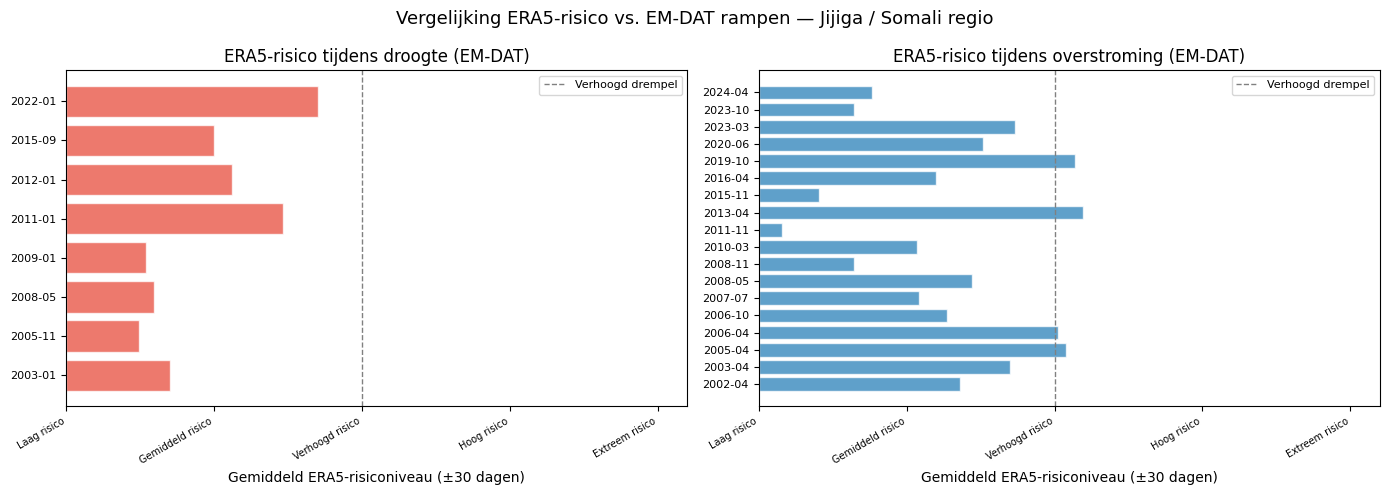

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rtype, color in zip(axes, ["Droogte", "Overstroming"], ["#e74c3c", "#2980b9"]):
    sub = summary[summary["type"] == rtype]
    if sub.empty:
        ax.text(0.5, 0.5, f"Geen {rtype.lower()} data",
                transform=ax.transAxes, ha="center", fontsize=12)
        ax.set_title(rtype)
        continue

    ax.barh(
        range(len(sub)),
        sub["risico_gem"],
        color=color, alpha=0.75, edgecolor="white"
    )
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [f"{r['start_date'].strftime('%Y-%m')}" for _, r in sub.iterrows()],
        fontsize=8,
    )
    ax.axvline(2, color="gray", ls="--", lw=1, label="Verhoogd drempel")
    ax.set_xlim(0, 4.2)
    ax.set_xticks(range(5))
    ax.set_xticklabels([r.value for r in RiskLevel], rotation=30, ha="right", fontsize=7)
    ax.set_xlabel("Gemiddeld ERA5-risiconiveau (±30 dagen)")
    ax.set_title(f"ERA5-risico tijdens {rtype.lower()} (EM-DAT)")
    ax.legend(fontsize=8)

fig.suptitle(f"Vergelijking ERA5-risico vs. EM-DAT rampen — {label_scope}", fontsize=13)
fig.tight_layout()
plt.savefig("emdat_risico_vergelijking.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Seizoenspatroon: EM-DAT vs. hoog ERA5-risico

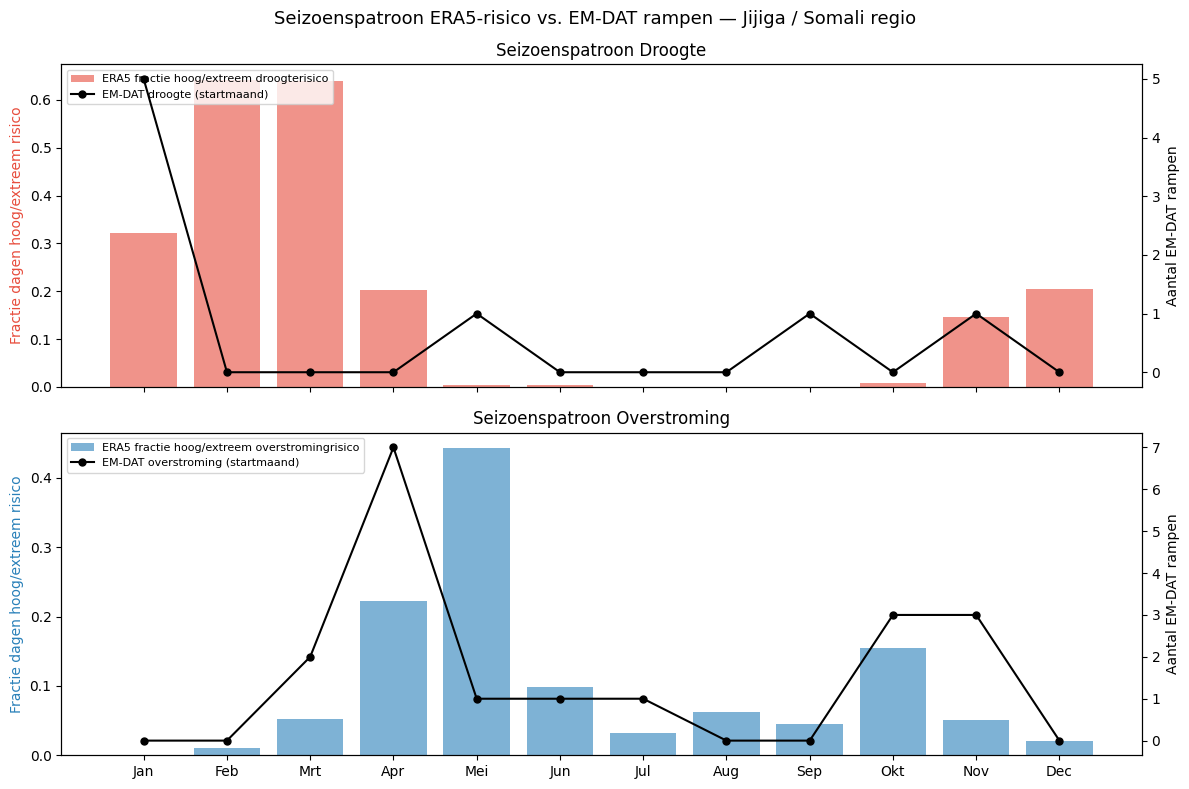

In [13]:
# Fractie dagen per maand met hoog/extreem risico (ERA5)
era5["month"] = era5.index.month

drought_high = (
    era5[era5["drought_num"] >= 3]
    .groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
    / era5.groupby("month").size()
)
flood_high = (
    era5[era5["flood_num"] >= 3]
    .groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
    / era5.groupby("month").size()
)

# EM-DAT ramp-startmaanden tellen
disaster_months = {
    "Droogte":      disasters[disasters[type_col].str.lower().str.contains("drought", na=False)]["start_date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0),
    "Overstroming": disasters[disasters[type_col].str.lower().str.contains("flood",   na=False)]["start_date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0),
} if type_col else {}

maanden = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
           "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]
x = np.arange(12)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, risk_series, color, label, key in [
    (axes[0], drought_high, "#e74c3c", "Droogte", "Droogte"),
    (axes[1], flood_high,   "#2980b9", "Overstroming", "Overstroming"),
]:
    bars = ax.bar(x, risk_series.values, color=color, alpha=0.6,
                  label=f"ERA5 fractie hoog/extreem {label.lower()}risico")
    ax.set_ylabel("Fractie dagen hoog/extreem risico", color=color)
    ax.set_title(f"Seizoenspatroon {label}")
    ax2 = ax.twinx()
    if key in disaster_months:
        ax2.plot(x, disaster_months[key].values, "o-", color="black",
                 lw=1.5, ms=5, label=f"EM-DAT {label.lower()} (startmaand)")
        ax2.set_ylabel("Aantal EM-DAT rampen", color="black")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(maanden)
fig.suptitle(f"Seizoenspatroon ERA5-risico vs. EM-DAT rampen — {label_scope}", fontsize=13)
fig.tight_layout()
plt.savefig("seizoen_vergelijking.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Samenvatting

In [14]:
n_drought = len(drought_events)
n_flood   = len(flood_events)

if not summary.empty:
    drought_sum = summary[summary["type"] == "Droogte"]
    flood_sum   = summary[summary["type"] == "Overstroming"]

    pct_drought_detected = (
        (drought_sum["risico_gem"] >= 2).sum() / max(len(drought_sum), 1) * 100
    )
    pct_flood_detected = (
        (flood_sum["risico_gem"] >= 2).sum() / max(len(flood_sum), 1) * 100
    )
else:
    pct_drought_detected = pct_flood_detected = float("nan")

print("=" * 60)
print("SAMENVATTING DATAVERGELIJKING")
print(f"Scope           : {label_scope}")
print(f"ERA5-periode    : {era5.index.min().date()} → {era5.index.max().date()}")
print("-" * 60)
print(f"EM-DAT droogten : {n_drought}")
print(f"EM-DAT overstromingen: {n_flood}")
print("-" * 60)
print(f"ERA5 detectie droogten (gem. ≥ 'Verhoogd')  : {pct_drought_detected:.0f}%")
print(f"ERA5 detectie overstromingen (gem. ≥ 'Verhoogd'): {pct_flood_detected:.0f}%")
print("=" * 60)
print()
print("Opmerking: ERA5 gridpunt (42.75°E / 9.25°N) is het dichtstbijzijnde")
print("  punt bij Jijiga City. Lokale topografie en microklimat kunnen")
print("  afwijken van EM-DAT veldwaarnemingen.")

SAMENVATTING DATAVERGELIJKING
Scope           : Jijiga / Somali regio
ERA5-periode    : 2000-01-01 → 2025-12-31
------------------------------------------------------------
EM-DAT droogten : 8
EM-DAT overstromingen: 18
------------------------------------------------------------
ERA5 detectie droogten (gem. ≥ 'Verhoogd')  : 0%
ERA5 detectie overstromingen (gem. ≥ 'Verhoogd'): 22%

Opmerking: ERA5 gridpunt (42.75°E / 9.25°N) is het dichtstbijzijnde
  punt bij Jijiga City. Lokale topografie en microklimat kunnen
  afwijken van EM-DAT veldwaarnemingen.
